
# Integration Module — Applying Part 1 effluent output to Part 2 Plant Growth Module_Checkpoint 2

This notebook integrates:
- upstream nitrification output from `simulate_part1_checkpoint2.py`
- fitted growth parameters from the growth-module notebook
- fitted uptake parameters from the uptake-module notebook

## What is included
1. **Usable-start vs quasi-steady-start comparison** using **Dynamic-μ only**  
   This section is meant to compare the effect of the two start definitions on the integrated simulation.

2. **All-method comparison** under the same upstream-driven nitrogen forcing  
   This section compares:
   - Dynamic-μ
   - RMND-μ
   - SMND-μ
   - Liebig minimum Monod
   - Multiplicative Monod

## Important modeling note
- Downstream nitrogen input is treated as a **forcing signal**:
  \[
  N(t) = NO_3(t) + NH_4(t)
  \]
- P and K are kept constant (P and K concentrations non-limiting).
- The **usable-start vs quasi-steady-start** section uses **Dynamic-μ only**.
- The **method-comparison** section uses **all growth methods**.


In [59]:

import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")


In [ ]:
# CONFIG

UPSTREAM_FILE = "simulate_part1_checkpoint2.py"
EXCEL_PATH = "/Users/yuming/Desktop/Folders/VerticalFarm/NPK.CrossT.All.xlsx"

# Exported parameter files from the two module notebooks
GROWTH_PARAMS_JSON = "checkpoint2_growth_outputs/fitted_growth_params_all.json"
UPTAKE_PARAMS_JSON = "checkpoint2_uptake_outputs/fitted_uptake_params_global.json"

# Choose the growth model to apply in the integrated run
MODEL_NAME = "dynamic"   # dynamic, rmnd, smnd, liebig, multiplicative

# If the selected model keeps P and K non-limiting (dynamic μ case)
DYNAMIC_PK_SOURCE = "MSS"  # MSS or MAX

# Crop cycle length (days). If None, infer from the dataset as max Growth Day.
CROP_CYCLE_DAYS = None

# -------- Usable-start rule (earlier start, around ~5 d) --------
# It is the earliest post-startup time at which the reactor output is considered usable
# for downstream illustration because basic aerobic operability is satisfied.
USE_MIN_DAY = 5.0
USE_DO_MIN = 7.5
USE_HOLD_DAYS = 3.0

# -------- Quasi-steady-state rule (later start, around ~35–40 d) --------
# Based on forward-window stability of total downstream-used N = NH4 + NO3.
QS_MIN_DAY = 5.0
QS_HOLD_DAYS = 10.0
QS_ABS_TOL = 0.05   # mg N/L

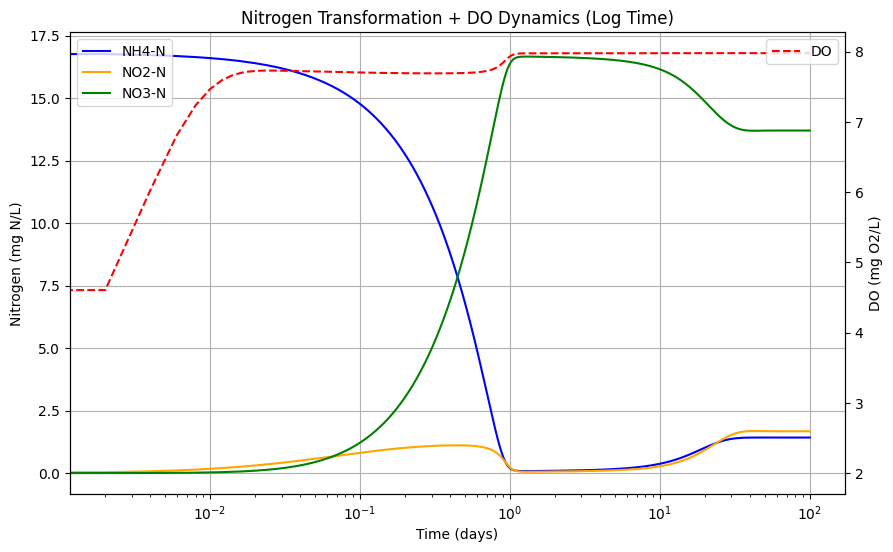

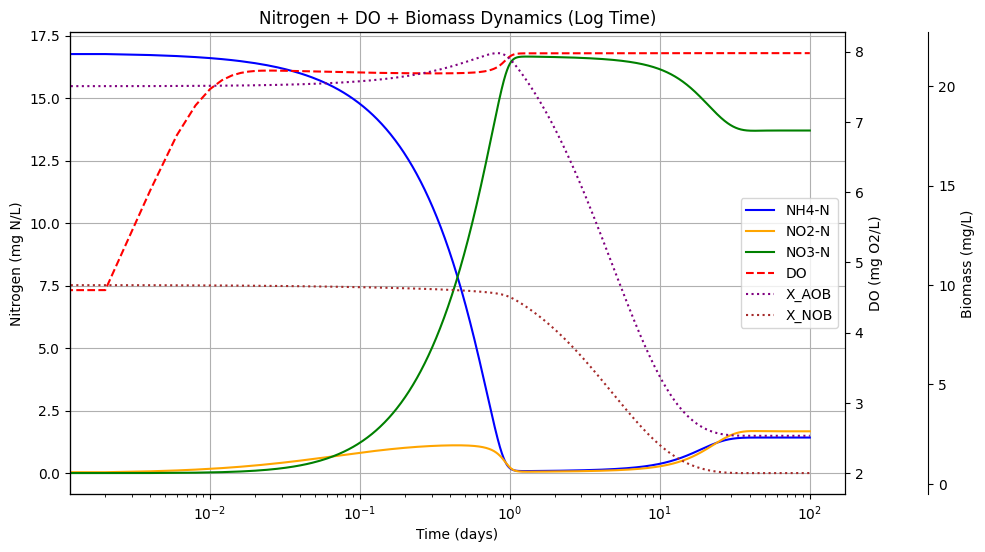

Upstream loaded: (50000, 6)
Time range: 0.0 to 100.0


In [76]:
def load_upstream_module(pyfile):
    spec = importlib.util.spec_from_file_location("upstream_mod", pyfile)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

up_mod = load_upstream_module(UPSTREAM_FILE)

t_up = np.asarray(up_mod.t, dtype=float)
sol_up = np.asarray(up_mod.sol, dtype=float)

NH4 = sol_up[:, 0]
NO2 = sol_up[:, 1]
NO3 = sol_up[:, 2]
DO  = sol_up[:, 3]
XAOB = sol_up[:, 4]
XNOB = sol_up[:, 5]

N_total = NH4 + NO3

print("Upstream loaded:", sol_up.shape)
print("Time range:", float(t_up.min()), "to", float(t_up.max()))

In [77]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

growth_params = load_json(GROWTH_PARAMS_JSON)
uptake_params = load_json(UPTAKE_PARAMS_JSON)

print("Growth models:", list(growth_params.keys()))
print("Uptake keys:", list(uptake_params.keys()))


Growth models: ['dynamic', 'rmnd', 'smnd', 'liebig', 'multiplicative']
Uptake keys: ['global']


In [ ]:
# Load dataset again for treatment summary / scenario constants

fit_df = pd.read_excel(EXCEL_PATH, sheet_name="ModSummary", header=1)

rename_map = {}
for c in fit_df.columns:
    cs = str(c).strip()
    if cs == "DM (g)":
        rename_map[c] = "DM"
    elif cs == "Treatment mg/L N":
        rename_map[c] = "N_target"
    elif cs == "Treatment mg/L P":
        rename_map[c] = "P_target"
    elif cs == "Treatment mg/L K":
        rename_map[c] = "K_target"
fit_df = fit_df.rename(columns=rename_map)

def normalize_category(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"N", "N-LIMITED", "N LIMITED"}:
        return "N"
    if s in {"P", "P-LIMITED", "P LIMITED"}:
        return "P"
    if s in {"K", "K-LIMITED", "K LIMITED"}:
        return "K"
    if s in {"MSS", "SUFFICIENT", "NUTRIENT SUFFICIENT", "CONTROL"}:
        return "MSS"
    return s

if "Category" in fit_df.columns:
    fit_df["Category"] = fit_df["Category"].apply(normalize_category)
elif "Limiting Nutrient" in fit_df.columns:
    fit_df["Category"] = fit_df["Limiting Nutrient"].apply(normalize_category)

required_cols = ["Treatment", "Growth Day", "DM", "Category"]
missing = [c for c in required_cols if c not in fit_df.columns]
if missing:
    raise ValueError(f"Missing required columns in ModSummary: {missing}")

# Try to get N/P/K from direct columns first; otherwise lifetime average columns
if "N" not in fit_df.columns:
    if "Lifetime Avg [N]" in fit_df.columns:
        fit_df["N"] = pd.to_numeric(fit_df["Lifetime Avg [N]"], errors="coerce")
    elif "Harvest [N] (mg/L)" in fit_df.columns:
        fit_df["N"] = pd.to_numeric(fit_df["Harvest [N] (mg/L)"], errors="coerce")

if "P" not in fit_df.columns:
    if "Lifetime Avg [P]" in fit_df.columns:
        fit_df["P"] = pd.to_numeric(fit_df["Lifetime Avg [P]"], errors="coerce")
    elif "Harvest [P] (mg/L)" in fit_df.columns:
        fit_df["P"] = pd.to_numeric(fit_df["Harvest [P] (mg/L)"], errors="coerce")

if "K" not in fit_df.columns:
    if "Lifetime Avg [K]" in fit_df.columns:
        fit_df["K"] = pd.to_numeric(fit_df["Lifetime Avg [K]"], errors="coerce")
    elif "Harvest [K] (mg/L)" in fit_df.columns:
        fit_df["K"] = pd.to_numeric(fit_df["Harvest [K] (mg/L)"], errors="coerce")

required_npk = ["N", "P", "K"]
missing_npk = [c for c in required_npk if c not in fit_df.columns]
if missing_npk:
    raise ValueError(f"Missing N/P/K columns in ModSummary: {missing_npk}")

fit_df = fit_df.dropna(subset=["Treatment", "Growth Day", "DM", "N", "P", "K", "Category"]).copy()
fit_df["Growth Day"] = pd.to_numeric(fit_df["Growth Day"], errors="coerce")
fit_df["DM"] = pd.to_numeric(fit_df["DM"], errors="coerce")
fit_df["N"] = pd.to_numeric(fit_df["N"], errors="coerce")
fit_df["P"] = pd.to_numeric(fit_df["P"], errors="coerce")
fit_df["K"] = pd.to_numeric(fit_df["K"], errors="coerce")
fit_df = fit_df.dropna(subset=["Growth Day", "DM", "N", "P", "K"]).copy()

if CROP_CYCLE_DAYS is None:
    CROP_CYCLE_DAYS = float(fit_df["Growth Day"].max())
    print(f"Inferred CROP_CYCLE_DAYS = {CROP_CYCLE_DAYS}")

fit_df.head()


Inferred CROP_CYCLE_DAYS = 32.0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Web Extension extension is not supported and will be removed
  warn(msg)
/var/folders/39/ycs6lphn0kx6yctvt5wzwyfm0000gn/T/ipykernel_71379/2966706030.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fit_df["Category"] = fit_df["Limiting Nutrient"].apply(normalize_category)
/var/folders/39/ycs6lphn0kx6yctvt5wzwyfm0000gn/T/ipykernel_71379/2966706030.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

,ID#,Limiting Nutrient,Treatment %,Round,Treatment,N_target,P_target,K_target,Growth Day,Pre/Post,...,Harvest [S] (mg/L),Lifetime Average [Fe],Harvest [Fe] (mg/L),Sample Period Avg [N],Sample Period Avg [P],Sample Period Avg [K],Category,N,P,K
0,1,MSS,1.0,R22,R22,132.0,31.0,210.0,0,-,...,NaN,0.717571,NaN,NaN,NaN,NaN,MSS,115.772222,21.627333,138.079303
7,8,MSS,1.0,R22,R22,132.0,31.0,210.0,14,Pre,...,24.660261,0.764942,0.764942,100.083333,18.252482,126.357798,MSS,110.744444,20.532344,138.326229
10,11,MSS,1.0,R22,R22,132.0,31.0,210.0,18,Pre,...,25.592071,0.759382,0.744555,62.375000,9.358332,88.899819,MSS,102.003535,18.410037,129.579032
12,13,MSS,1.0,R22,R22,132.0,31.0,210.0,21,Pre,...,27.751510,0.775276,0.862690,80.127500,14.822822,111.995423,MSS,98.637991,17.858158,126.873861
16,17,MSS,1.0,R22,R22,132.0,31.0,210.0,25,Pre,...,29.167895,0.769083,0.748955,73.650000,11.129188,115.239943,MSS,94.198660,16.323061,126.085750


In [ ]:

# Start-time detection

def first_usable_start_time(t, do, min_day=5.0, do_min=7.5, hold_days=3.0):
    """
    Early usable start time:
    earliest time after min_day such that DO stays above do_min for a short hold window.
    This gives an 'early operable / usable' start, not a quasi-steady-state start.
    """
    t = np.asarray(t, dtype=float)
    do = np.asarray(do, dtype=float)

    for i in range(len(t)):
        if t[i] < min_day:
            continue
        t_end = t[i] + hold_days
        j = np.searchsorted(t, t_end, side="right") - 1
        if j <= i:
            continue
        if np.all(do[i:j+1] >= do_min):
            return float(t[i]), {
                "do_min": float(do_min),
                "hold_days": float(hold_days),
                "min_day": float(min_day)
            }
    return float(min_day), None

def first_quasi_steady_time_totalN(t, n_total, min_day=5.0, hold_days=10.0, abs_tol=0.05):
    """
    Strict quasi-steady-state start based on forward-window stability of total N.
    Find earliest t >= min_day such that max deviation over [t, t+hold_days] is <= abs_tol.
    """
    t = np.asarray(t, dtype=float)
    n_total = np.asarray(n_total, dtype=float)

    for i in range(len(t)):
        if t[i] < min_day:
            continue
        t_end = t[i] + hold_days
        j = np.searchsorted(t, t_end, side="right") - 1
        if j <= i:
            continue
        ref = n_total[i]
        y_win = n_total[i:j+1]
        max_dev = float(np.max(np.abs(y_win - ref)))
        if max_dev <= abs_tol:
            return float(t[i]), {
                "hold_days": float(hold_days),
                "abs_tol": float(abs_tol),
                "max_dev": max_dev
            }
    return float(t[-1] - hold_days), None

usable_start, usable_info = first_usable_start_time(
    t_up, DO,
    min_day=USE_MIN_DAY,
    do_min=USE_DO_MIN,
    hold_days=USE_HOLD_DAYS
)

qs_start, qs_info = first_quasi_steady_time_totalN(
    t_up, N_total,
    min_day=QS_MIN_DAY,
    hold_days=QS_HOLD_DAYS,
    abs_tol=QS_ABS_TOL
)

print("Usable start time =", usable_start)
print("Usable-start info =", usable_info)
print("Quasi-steady start time =", qs_start)
print("Quasi-steady info =", qs_info)


Usable start time = 5.00010000200004
Usable-start info = {'do_min': 7.5, 'hold_days': 3.0, 'min_day': 5.0}
Quasi-steady start time = 33.98067961359227
Quasi-steady info = {'hold_days': 10.0, 'abs_tol': 0.05, 'max_dev': 0.04997500726838844}


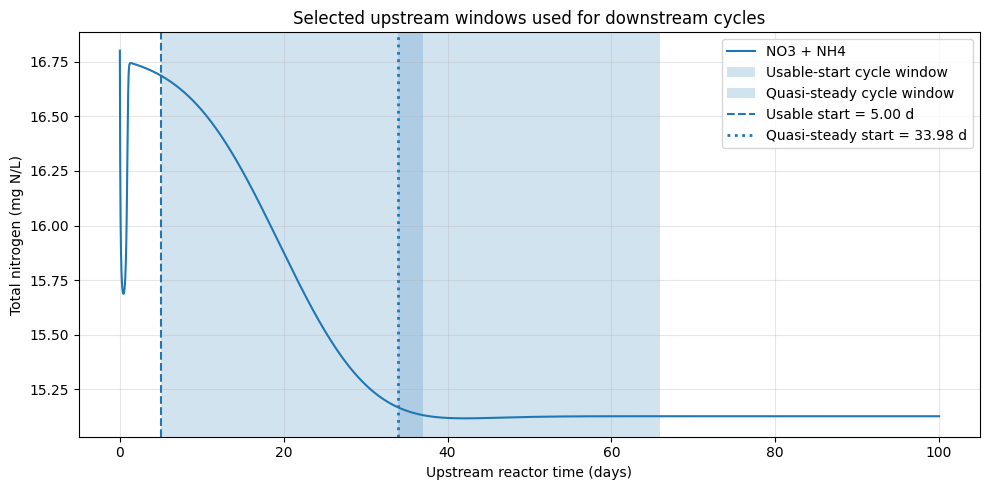

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(t_up, N_total, label="NO3 + NH4")
plt.axvspan(usable_start, usable_start + CROP_CYCLE_DAYS, alpha=0.20, label="Usable-start cycle window")
plt.axvspan(qs_start, qs_start + CROP_CYCLE_DAYS, alpha=0.20, label="Quasi-steady cycle window")
plt.axvline(usable_start, linestyle="--", label=f"Usable start = {usable_start:.2f} d")
plt.axvline(qs_start, linestyle=":", linewidth=2, label=f"Quasi-steady start = {qs_start:.2f} d")
plt.xlabel("Upstream reactor time (days)")
plt.ylabel("Total nitrogen (mg N/L)")
plt.title("Selected upstream windows used for downstream cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Treatment summary and matching

treat_summary = (
    fit_df.groupby("Treatment", as_index=False)
    .agg(
        N_mean=("N", "mean"),
        P_mean=("P", "mean"),
        K_mean=("K", "mean"),
        Category=("Category", "first"),
        B0=("DM", "first")
    )
)

def cycle_mean_total_n(t, n_total, start, duration):
    mask = (t >= start) & (t <= start + duration)
    if not np.any(mask):
        return np.nan
    return float(np.mean(n_total[mask]))

def match_treatment_by_cycle_mean_N(cycle_mean_n, treat_summary_df):
    idx = int(np.argmin(np.abs(treat_summary_df["N_mean"].values - cycle_mean_n)))
    return treat_summary_df.iloc[idx]

usable_meanN = cycle_mean_total_n(t_up, N_total, usable_start, CROP_CYCLE_DAYS)
qs_meanN = cycle_mean_total_n(t_up, N_total, qs_start, CROP_CYCLE_DAYS)

usable_match = match_treatment_by_cycle_mean_N(usable_meanN, treat_summary)
qs_match = match_treatment_by_cycle_mean_N(qs_meanN, treat_summary)

print("Usable-start cycle mean N:", usable_meanN)
display(usable_match.to_frame().T)
print("Quasi-steady cycle mean N:", qs_meanN)
display(qs_match.to_frame().T)

Usable-start cycle mean N: 15.845918369350514


,Treatment,N_mean,P_mean,K_mean,Category,B0
1,R09N,17.437497,51.841473,151.829072,N,0.001878


Quasi-steady cycle mean N: 15.126201032575047


,Treatment,N_mean,P_mean,K_mean,Category,B0
1,R09N,17.437497,51.841473,151.829072,N,0.001878


In [ ]:
# Growth and uptake helpers

def frac_monod(s, ks):
    s = max(float(s), 1e-12)
    ks = max(float(ks), 1e-12)
    return s / (ks + s)

def michaelis_menten(n, umax, km):
    n = np.asarray(n, dtype=float)
    n = np.clip(n, 0.0, None)
    return umax * n / (km + n + 1e-12)

def get_nonlimiting_pk(df, source="MSS"):
    source = str(source).strip().upper()
    if source == "MSS":
        mss = df[df["Category"] == "MSS"]
        if len(mss) > 0:
            return float(mss["P"].mean()), float(mss["K"].mean())
    return float(df["P"].max()), float(df["K"].max())

PK_NONLIMITING = get_nonlimiting_pk(fit_df, source=DYNAMIC_PK_SOURCE)

def calc_mu(model_name, t_crop, n_t, p_const, k_const, category, params):
    if model_name == "dynamic":
        return max(
            params["mu_max"] * frac_monod(n_t, params["Ks"])
            + params["m"] * max(0.0, t_crop - params["delay"]),
            0.0
        )
    elif model_name == "rmnd":
        mu_key = f"mu_max_{category}"
        m_key = f"m_{category}"
        d_key = f"delay_{category}"
        mu = params[mu_key]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        mu += params[m_key] * max(0.0, t_crop - params[d_key])
        return max(mu, 0.0)
    elif model_name == "smnd":
        mu = params["mu_max"]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        mu += params["m"] * max(0.0, t_crop - params["delay"])
        return max(mu, 0.0)
    elif model_name == "liebig":
        fmin = min(
            frac_monod(n_t, params["KsN"]),
            frac_monod(p_const, params["KsP"]),
            frac_monod(k_const, params["KsK"]),
        )
        return max(params["mu_max"] * fmin, 0.0)
    elif model_name == "multiplicative":
        mu = params["mu_max"]
        mu *= frac_monod(n_t, params["KsN"])
        mu *= frac_monod(p_const, params["KsP"])
        mu *= frac_monod(k_const, params["KsK"])
        return max(mu, 0.0)
    else:
        raise ValueError(f"Unknown MODEL_NAME: {model_name}")

def get_growth_param_dict(model_name, growth_params_json):
    if model_name not in growth_params_json:
        raise KeyError(f"{model_name} not found in growth parameter JSON.")
    params = dict(growth_params_json[model_name])
    params.pop("success", None)
    params.pop("objective", None)
    return params

def get_uptake_param_dict(uptake_params_json):
    if "global" in uptake_params_json:
        params = dict(uptake_params_json["global"])
    else:
        params = dict(uptake_params_json)
    params.pop("metrics", None)
    params.pop("x_col", None)
    params.pop("y_col", None)
    params.pop("sheet_name", None)
    params.pop("screen_col", None)
    return params

In [ ]:
# Uptake model helpers
def michaelis_menten(n, umax, km):
    n = np.asarray(n, dtype=float)
    n = np.clip(n, 0.0, None)
    return umax * n / (km + n + 1e-12)

def simulate_uptake(forcing, uptake_params):
    n_series = np.asarray(forcing["N"], dtype=float)
    u = michaelis_menten(n_series, uptake_params["Umax"], uptake_params["Km"])
    return {
        "t_crop": np.asarray(forcing["t"], dtype=float),
        "uptake": u
    }

uptake_global = uptake_params_all["global"]

## A. Usable-start vs quasi-steady-start comparison 
Growth module using Dynamic-μ simulation.

In [ ]:
# Integrated cycle simulation

def simulate_cycle(model_name, cycle_start, cycle_days, matched_row):
    mask = (t_up >= cycle_start) & (t_up <= cycle_start + cycle_days)
    if not np.any(mask):
        raise ValueError("Selected cycle window contains no upstream points.")

    t_window = t_up[mask]
    n_window = N_total[mask]

    # Re-index to crop age
    t_crop = t_window - t_window[0]

    category = str(matched_row["Category"])
    B0 = float(matched_row["B0"])
    p_const = float(matched_row["P_mean"])
    k_const = float(matched_row["K_mean"])

    if model_name == "dynamic":
        p_const, k_const = PK_NONLIMITING

    gpars = get_growth_param_dict(model_name, growth_params)
    upars = get_uptake_param_dict(uptake_params)

    mu_series = np.array([
        calc_mu(model_name, tc, n_t, p_const, k_const, category, gpars)
        for tc, n_t in zip(t_crop, n_window)
    ], dtype=float)

    U_series = michaelis_menten(n_window, upars["Umax"], upars["Km"])

    DM = np.zeros_like(t_crop, dtype=float)
    dDMdt = np.zeros_like(t_crop, dtype=float)
    DM[0] = B0
    dDMdt[0] = mu_series[0] * DM[0]

    for i in range(1, len(t_crop)):
        dt = float(t_crop[i] - t_crop[i - 1])
        DM[i] = DM[i - 1] * np.exp(mu_series[i - 1] * dt)
        dDMdt[i] = mu_series[i] * DM[i]

    return {
        "start": float(cycle_start),
        "duration": float(cycle_days),
        "matched_treatment": str(matched_row["Treatment"]),
        "category": category,
        "P_const": p_const,
        "K_const": k_const,
        "B0": B0,
        "t_up_window": t_window,
        "t_crop": t_crop,
        "N_input": n_window,
        "mu": mu_series,
        "U": U_series,
        "DM": DM,
        "dDMdt": dDMdt,
    }
MODEL_NAME
sim_usable = simulate_cycle(MODEL_NAME, usable_start, CROP_CYCLE_DAYS, usable_match)
sim_qs = simulate_cycle(MODEL_NAME, qs_start, CROP_CYCLE_DAYS, qs_match)

print("Usable-start cycle matched treatment:", sim_usable["matched_treatment"], "| category:", sim_usable["category"])
print("Quasi-steady cycle matched treatment:", sim_qs["matched_treatment"], "| category:", sim_qs["category"])


Usable-start cycle matched treatment: R09N | category: N
Quasi-steady cycle matched treatment: R09N | category: N


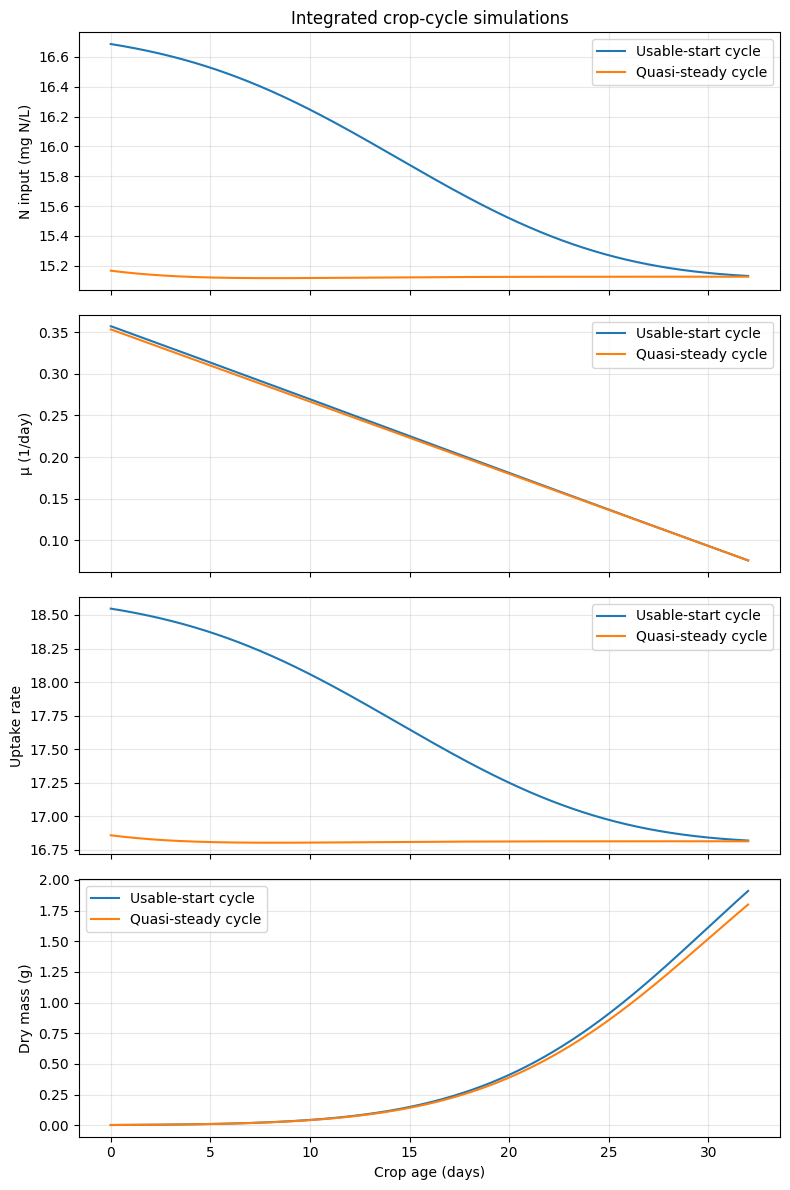

In [ ]:
# Integrated plots

fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axes[0].plot(sim_usable["t_crop"], sim_usable["N_input"], label="Usable-start cycle")
axes[0].plot(sim_qs["t_crop"], sim_qs["N_input"], label="Quasi-steady cycle")
axes[0].set_ylabel("N input (mg N/L)")
axes[0].set_title("Integrated crop-cycle simulations")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(sim_usable["t_crop"], sim_usable["mu"], label="Usable-start cycle")
axes[1].plot(sim_qs["t_crop"], sim_qs["mu"], label="Quasi-steady cycle")
axes[1].set_ylabel("μ (1/day)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(sim_usable["t_crop"], sim_usable["U"], label="Usable-start cycle")
axes[2].plot(sim_qs["t_crop"], sim_qs["U"], label="Quasi-steady cycle")
axes[2].set_ylabel("Uptake rate")
axes[2].grid(True, alpha=0.3)

axes[3].plot(sim_usable["t_crop"], sim_usable["DM"], label="Usable-start cycle")
axes[3].plot(sim_qs["t_crop"], sim_qs["DM"], label="Quasi-steady cycle")
axes[3].set_ylabel("Dry mass (g)")
axes[3].set_xlabel("Crop age (days)")
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()


## B. All-method comparison

This section compares **all growth methods** under the same upstream-driven nitrogen forcing.
The uptake model remains the same Michaelis–Menten model.


In [88]:
MODEL_DISPLAY = {
    "dynamic": "Dynamic μ",
    "rmnd": "RMND μ",
    "smnd": "SMND μ",
    "liebig": "Liebig minimum Monod",
    "multiplicative": "Multiplicative Monod",
}

growth_models = ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]

all_methods_usable = {}
all_methods_qs = {}

for model_name in growth_models:
    all_methods_usable[model_name] = simulate_cycle(
        model_name, usable_start, CROP_CYCLE_DAYS, usable_match
    )
    all_methods_qs[model_name] = simulate_cycle(
        model_name, qs_start, CROP_CYCLE_DAYS, qs_match
    )

print("Completed all-method integrated simulations.")

Completed all-method integrated simulations.


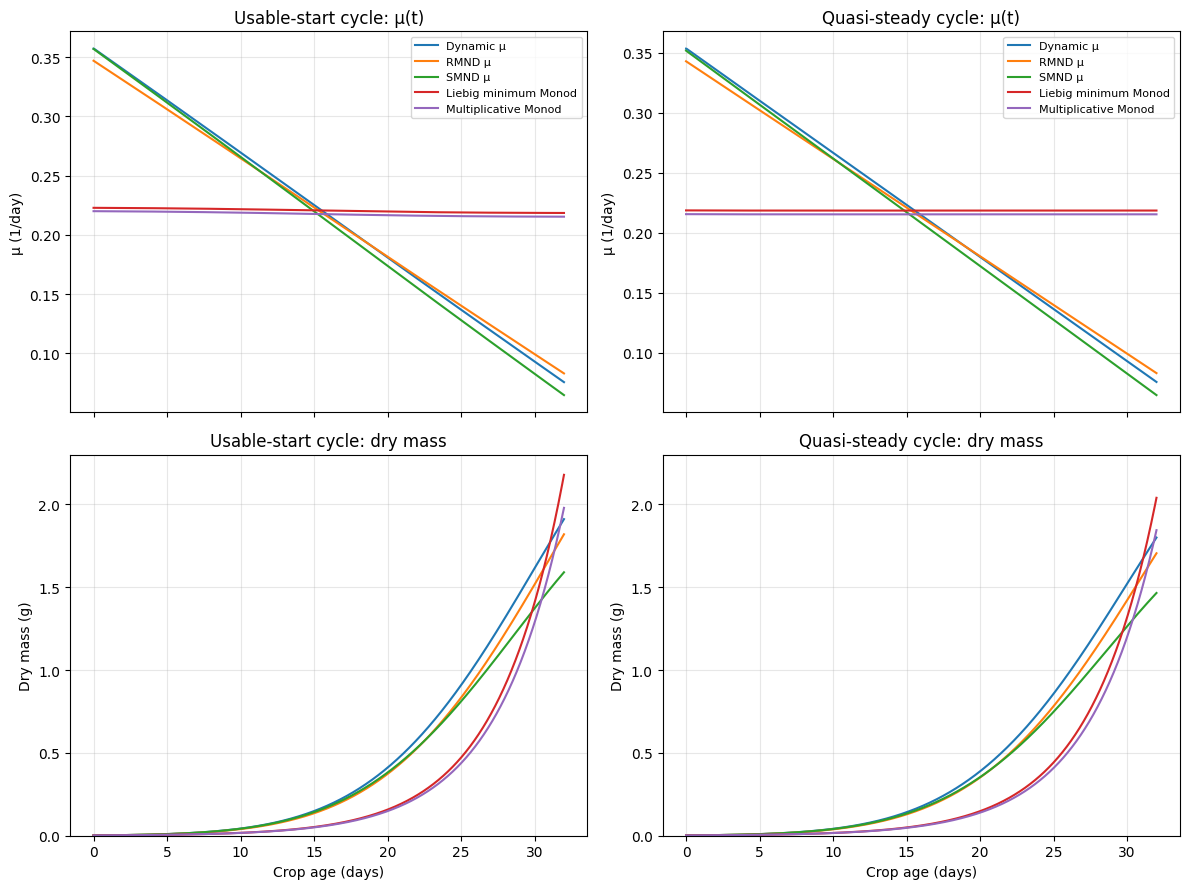

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

# μ(t) for usable cycle
for model_name in growth_models:
    axes[0, 0].plot(
        all_methods_usable[model_name]["t_crop"],
        all_methods_usable[model_name]["mu"],
        label=MODEL_DISPLAY[model_name]
    )
axes[0, 0].set_title("Usable-start cycle: μ(t)")
axes[0, 0].set_ylabel("μ (1/day)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

# DM(t) for usable cycle
for model_name in growth_models:
    axes[1, 0].plot(
        all_methods_usable[model_name]["t_crop"],
        all_methods_usable[model_name]["DM"],
        label=MODEL_DISPLAY[model_name]
    )
axes[1, 0].set_title("Usable-start cycle: dry mass")
axes[1, 0].set_xlabel("Crop age (days)")
axes[1, 0].set_ylabel("Dry mass (g)")
axes[1, 0].set_ylim(0, 2.3)
axes[1, 0].grid(True, alpha=0.3)

# μ(t) for quasi-steady cycle
for model_name in growth_models:
    axes[0, 1].plot(
        all_methods_qs[model_name]["t_crop"],
        all_methods_qs[model_name]["mu"],
        label=MODEL_DISPLAY[model_name]
    )
axes[0, 1].set_title("Quasi-steady cycle: μ(t)")
axes[0, 1].set_ylabel("μ (1/day)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

# DM(t) for quasi-steady cycle
for model_name in growth_models:
    axes[1, 1].plot(
        all_methods_qs[model_name]["t_crop"],
        all_methods_qs[model_name]["DM"],
        label=MODEL_DISPLAY[model_name]
    )
axes[1, 1].set_title("Quasi-steady cycle: dry mass")
axes[1, 1].set_xlabel("Crop age (days)")
axes[1, 1].set_ylabel("Dry mass (g)")
axes[1, 1].set_ylim(0, 2.3)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [94]:
# Save summary tables
summary_rows = []

for cycle_name, sims in [("usable", all_methods_usable), ("quasi_steady", all_methods_qs)]:
    for model_name, sim in sims.items():
        summary_rows.append({
            "cycle": cycle_name,
            "model": model_name,
            "mu_start": float(sim["mu"][0]),
            "mu_end": float(sim["mu"][-1]),
            "DM_start": float(sim["DM"][0]),
            "DM_end": float(sim["DM"][-1]),
            "dDMdt_start": float(sim["dDMdt"][0]),
            "dDMdt_end": float(sim["dDMdt"][-1]),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,cycle,model,mu_start,mu_end,DM_start,DM_end,dDMdt_start,dDMdt_end
0,usable,dynamic,0.357210,0.075608,0.001878,1.910671,0.000671,0.144461
1,usable,rmnd,0.347015,0.082972,0.001878,1.819216,0.000652,0.150944
2,usable,smnd,0.356979,0.064657,0.001878,1.589899,0.000671,0.102797
3,usable,liebig,0.222806,0.218466,0.001878,2.178076,0.000419,0.475836
4,usable,multiplicative,0.219973,0.215320,0.001878,1.978689,0.000413,0.426052
5,quasi_steady,dynamic,0.353363,0.075594,0.001878,1.799555,0.000664,0.136035
6,quasi_steady,rmnd,0.342837,0.082957,0.001878,1.704628,0.000644,0.141411
7,quasi_steady,smnd,0.351718,0.064638,0.001878,1.464967,0.000661,0.094692
8,quasi_steady,liebig,0.218573,0.218451,0.001878,2.039441,0.000411,0.445519
9,quasi_steady,multiplicative,0.215434,0.215304,0.001878,1.844047,0.000405,0.397031


In [ ]:
summary_df.to_csv(OUTPUT_DIR / "integration_growth_method_summary.csv", index=False)
print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: checkpoint2_integration_outputs
